# Message Count Over Time

Visualization of message counts per date from the Usenet archive.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

In [2]:
def load_date_counts(path):
    df = pd.read_csv(path)
    num_unknown = df[df.date == "unknown"]["count"].item()
    print(f"Number of messages with unknown date in {path}: {num_unknown}")
    df = df[df["date"] != "unknown"]
    df["date"] = pd.to_datetime(df["date"])
    return df.sort_values("date")


df_ia = load_date_counts("../data/date_count_ia.csv")
df_nwa = load_date_counts("../data/date_count_nwa.csv")
df_ia.head()

Number of messages with unknown date in ../data/date_count_ia.csv: 3167
Number of messages with unknown date in ../data/date_count_nwa.csv: 587


,date,count
0,1991-01-23,1
1,1992-04-04,3
2,1992-05-09,1
3,1992-07-20,3
4,1992-07-25,4


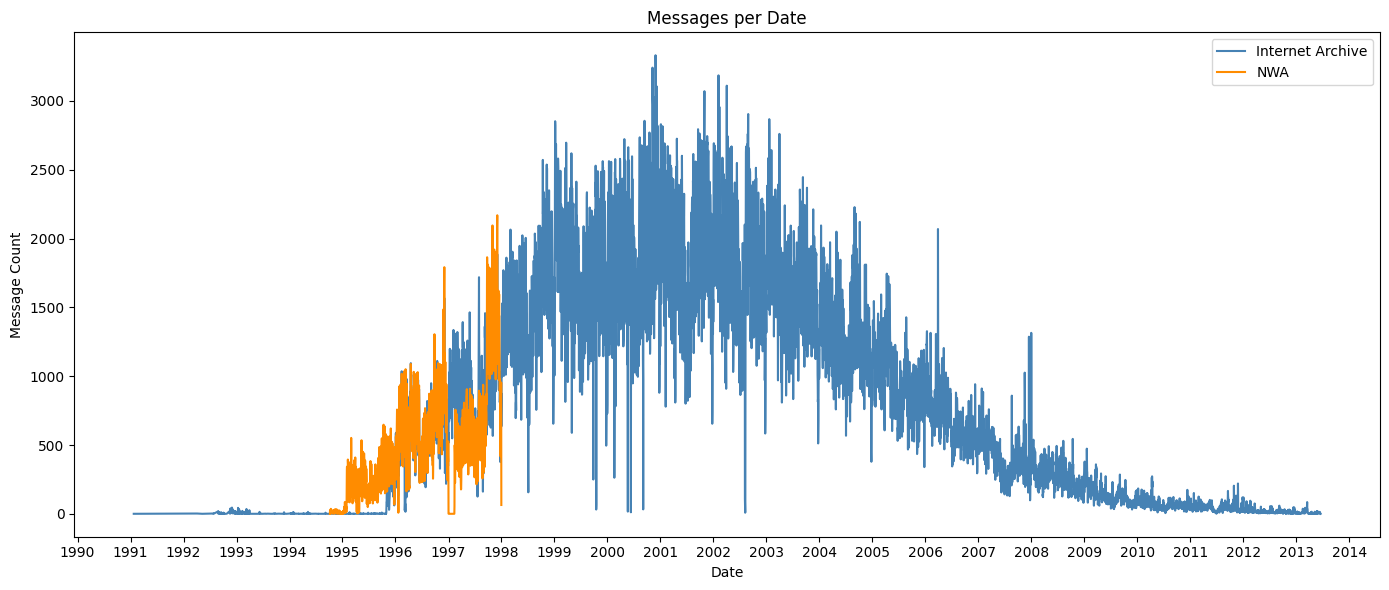

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_ia["date"], df_ia["count"], label="Internet Archive", color="steelblue")
ax.plot(df_nwa["date"], df_nwa["count"], label="NWA", color="darkorange")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Date")
ax.set_ylabel("Message Count")
ax.set_title("Messages per Date")
ax.legend()
plt.tight_layout()
plt.show()

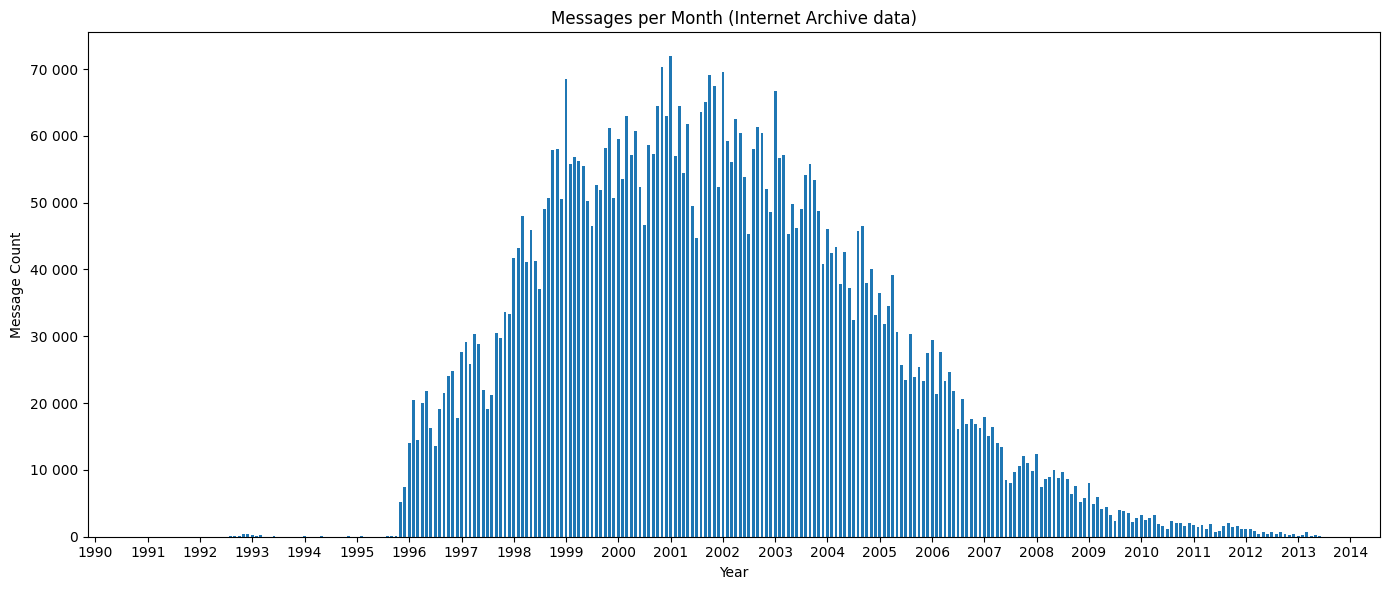

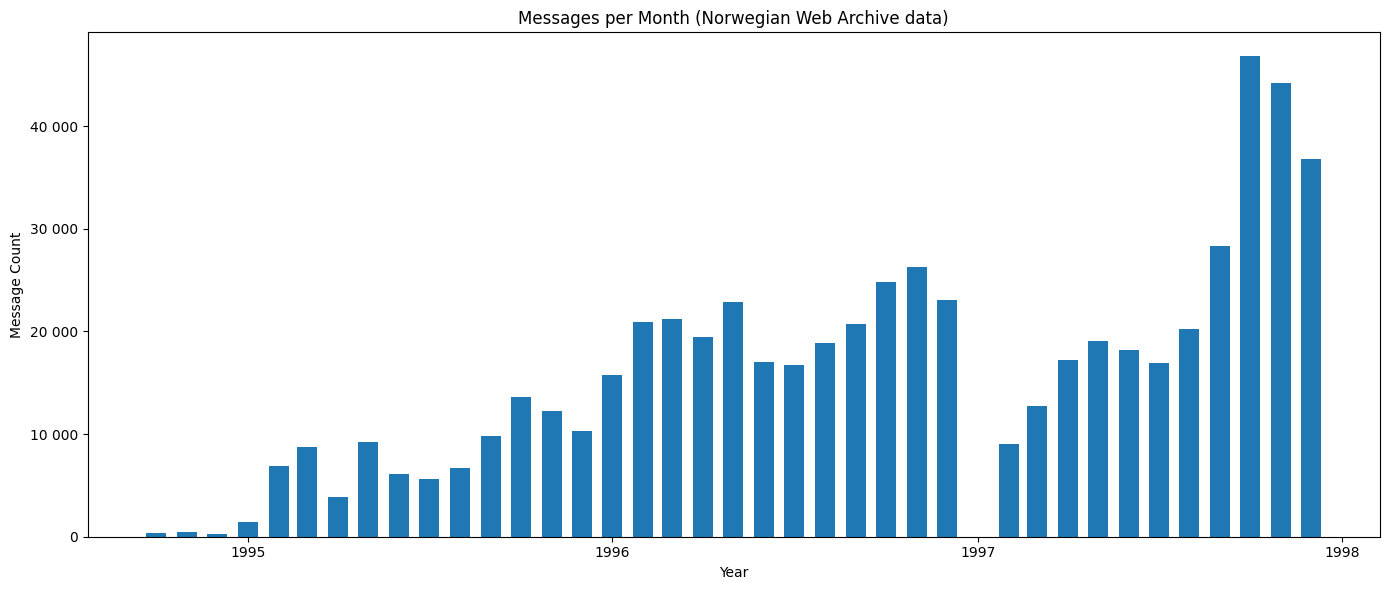

In [4]:
# Monthly aggregation
def plot_per_month(df: pd.DataFrame, name: str):
    df["month"] = df["date"].dt.to_period("M")
    monthly = df.groupby("month")["count"].sum().reset_index()
    monthly["month"] = monthly["month"].dt.to_timestamp()

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(monthly["month"], monthly["count"], width=20)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda value, _: f"{value:,.0f}".replace(",", " "))
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Message Count")
    ax.set_title(f"Messages per Month ({name})")
    plt.tight_layout()
    plt.show()


plot_per_month(df_ia, "Internet Archive data")
plot_per_month(df_nwa, "Norwegian Web Archive data")

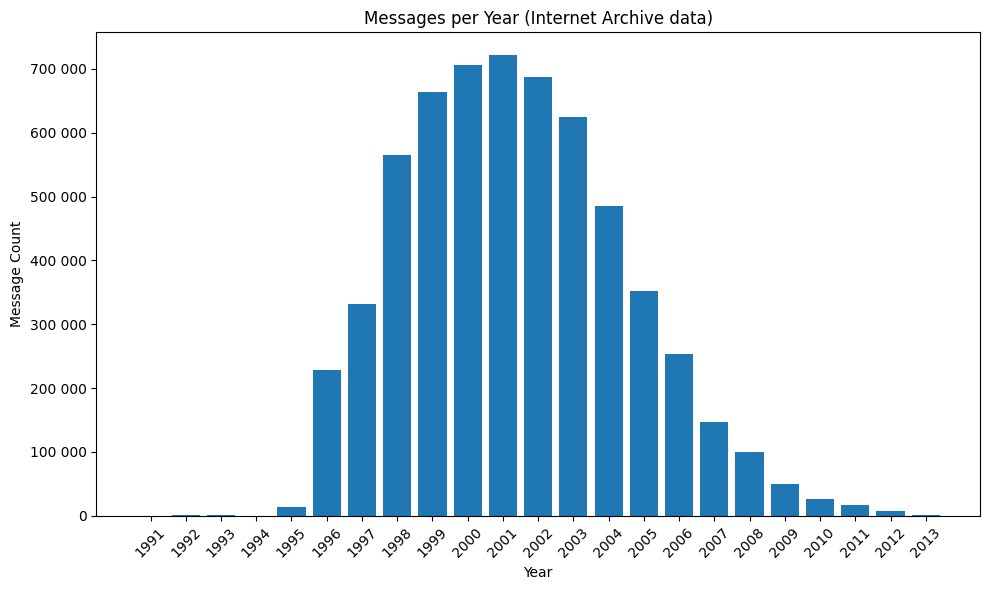

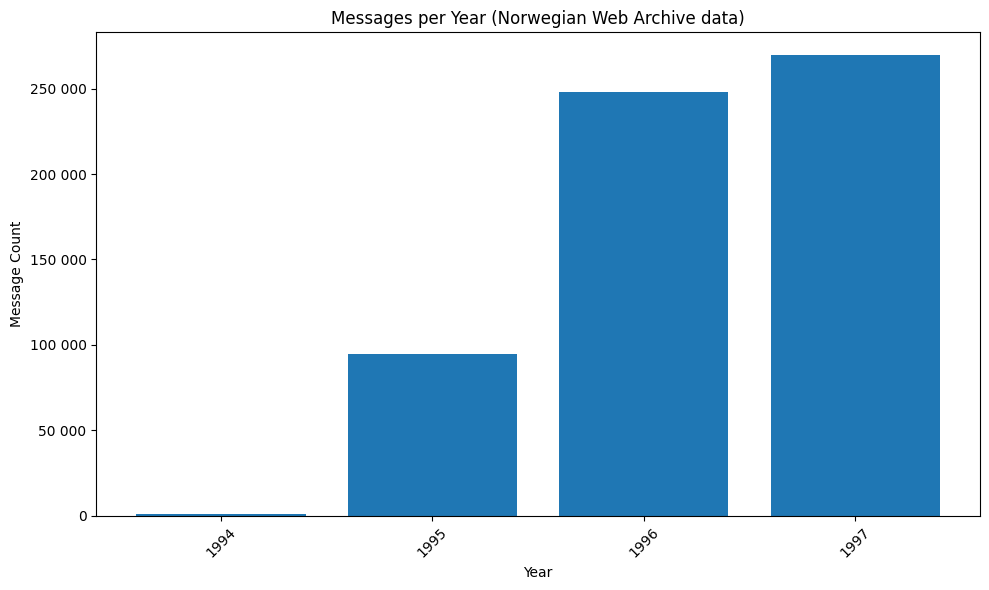

In [5]:
# Yearly aggregation
def plot_per_year(df: pd.DataFrame, name: str):
    df["year"] = df["date"].dt.year
    yearly = df.groupby("year")["count"].sum().reset_index()

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(yearly["year"], yearly["count"])
    ax.set_xticks(yearly["year"])
    ax.set_xticklabels(yearly["year"], rotation=45)
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda value, _: f"{value:,.0f}".replace(",", " "))
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Message Count")
    ax.set_title(f"Messages per Year ({name})")
    plt.tight_layout()
    plt.show()


plot_per_year(df_ia, "Internet Archive data")
plot_per_year(df_nwa, "Norwegian Web Archive data")